# 02 · Cleaning and Validation

Clean, type and check the data. The logic is in `src/seer_survival/data.py`, so the app and training script use the same rules.

Values that are clinically unexpected but possible are flagged, not edited.

In [1]:
import sys, warnings
from pathlib import Path

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(ROOT / "src"))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from seer_survival import config as C
from seer_survival.data import load_raw, clean, validate, consistency_flags, derive_stage_6th
from seer_survival.plots import set_style, save_fig

set_style()
pd.set_option("display.width", 160)

## 1. Apply the cleaning function

In [2]:
raw = load_raw()
df = clean(raw)

before_after = pd.DataFrame({
    "raw column": [c for c in raw.columns if c.strip() in C.RAW_TO_CLEAN],
})
before_after["clean column"] = before_after["raw column"].str.strip().map(C.RAW_TO_CLEAN)
before_after["raw dtype"] = [str(raw[c].dtype) for c in before_after["raw column"]]
before_after["clean dtype"] = [str(df[c].dtype) for c in before_after["clean column"]]
before_after["raw column"] = before_after["raw column"].map(repr)
print("Dropped columns:", [c for c in raw.columns if c.strip() not in C.RAW_TO_CLEAN])
print("Added columns:  ", [c for c in df.columns if c not in C.RAW_TO_CLEAN.values()])
before_after

Dropped columns: ['Unnamed: 3']
Added columns:   ['event']


,raw column,clean column,raw dtype,clean dtype
0,'Age',age,int64,int64
1,'Race ',race,object,object
2,'Marital Status',marital_status,object,object
3,'T Stage ',t_stage,object,object
4,'N Stage',n_stage,object,object
5,'6th Stage',stage_6th,object,object
6,'Grade',grade,object,int64
7,'A Stage',a_stage,object,object
8,'Tumor Size',tumor_size,int64,int64
9,'Estrogen Status',estrogen_status,object,object


In [3]:
df.head()

,age,race,marital_status,t_stage,n_stage,stage_6th,grade,a_stage,tumor_size,estrogen_status,progesterone_status,nodes_examined,nodes_positive,survival_months,status,event
0,43,Other,Married,T2,N3,IIIC,2,Regional,40,Positive,Positive,19,11,1,Alive,0
1,47,Other,Married,T2,N2,IIIA,2,Regional,45,Positive,Positive,25,9,2,Alive,0
2,67,White,Married,T2,N1,IIB,3,Regional,25,Positive,Positive,4,1,2,Dead,1
3,46,White,Divorced,T1,N1,IIA,2,Regional,19,Positive,Positive,26,1,2,Dead,1
4,63,White,Married,T2,N2,IIIA,2,Regional,35,Positive,Positive,21,5,3,Dead,1


### Conversions applied

| Column | Conversion | Reason |
|---|---|---|
| `grade` | text → ordinal integer 1–4 | "Well / Moderately / Poorly / Undifferentiated" are ordered |
| `race` | long label → `White / Black / Other` | shorter labels for plots and app; no information lost |
| `marital_status` | long label → short label | same |
| `event` | new: 1 if `status == "Dead"` | survival models need a 0/1 event indicator |

In [4]:
print(pd.crosstab(raw["Grade"], df["grade"]))

grade                                     1     2     3   4
Grade                                                      
Moderately differentiated; Grade II       0  2351     0   0
Poorly differentiated; Grade III          0     0  1111   0
Undifferentiated; anaplastic; Grade IV    0     0     0  19
Well differentiated; Grade I            543     0     0   0


## 2. Validation report

`[hard]` checks must pass, otherwise the data is unusable. `[soft]` checks describe clinically unexpected patterns.

In [5]:
report = validate(df).to_frame()
report.style.apply(lambda r: ["background-color:#fde0d9" if not r.passed else "" for _ in r], axis=1)

,name,passed,n_violations,detail
0,[hard] schema matches,True,0,"missing=set(), extra=set()"
1,[hard] no missing values,True,0,
2,[hard] age within 18-100,True,0,
3,[hard] tumor_size > 0,True,0,
4,[hard] nodes_examined >= 1,True,0,
5,[hard] nodes_positive <= nodes_examined,True,0,
6,[hard] survival_months >= 1,True,0,
7,[hard] t_stage in allowed levels,True,0,
8,[hard] n_stage in allowed levels,True,0,
9,[hard] stage_6th in allowed levels,True,0,


In [6]:
assert validate(df).hard_failures == [], "hard validation failed"
print("All hard checks passed.")

All hard checks passed.


## 3. Is `stage_6th` redundant?

Check whether the AJCC 6th-edition stage group can be derived from T and N for every patient.

In [7]:
derived = np.array([derive_stage_6th(t, n) for t, n in zip(df.t_stage, df.n_stage)])
agree = (derived == df.stage_6th.to_numpy()).mean()
print(f"Agreement between recorded and AJCC-derived stage: {agree:.2%}")
pd.crosstab([df.t_stage, df.n_stage], df.stage_6th)

Agreement between recorded and AJCC-derived stage: 100.00%


stage_6th         IIA   IIB  IIIA  IIIB  IIIC
t_stage n_stage                              
T1      N1       1305     0     0     0     0
        N2          0     0   211     0     0
        N3          0     0     0     0    87
T2      N1          0  1130     0     0     0
        N2          0     0   428     0     0
        N3          0     0     0     0   228
T3      N1          0     0   262     0     0
        N2          0     0   149     0     0
        N3          0     0     0     0   122
T4      N1          0     0     0    35     0
        N2          0     0     0    32     0
        N3          0     0     0     0    35

**Result:** H2 holds (100 % agreement). `stage_6th` adds no information beyond T and N. It is kept for EDA but **excluded from model inputs** to avoid perfect collinearity.

## 4. Clinical consistency flags

AJCC 6th edition (Greene et al., 2002): T1 ≤ 20 mm, T2 21–50 mm, T3 > 50 mm; pN1 1–3, pN2 4–9, pN3 ≥ 10 positive nodes.

SEER's T and N can also reflect extension or non-axillary nodes, so a mismatch is not necessarily an error.

In [8]:
flags = consistency_flags(df)
print(flags.sum().to_string())
print(f"\nRows with at least one flag: {flags.any(axis=1).sum()} ({flags.any(axis=1).mean():.1%})")

flag_t1_size      0
flag_t2_size      0
flag_t3_size      7
flag_n_count    101

Rows with at least one flag: 107 (2.7%)


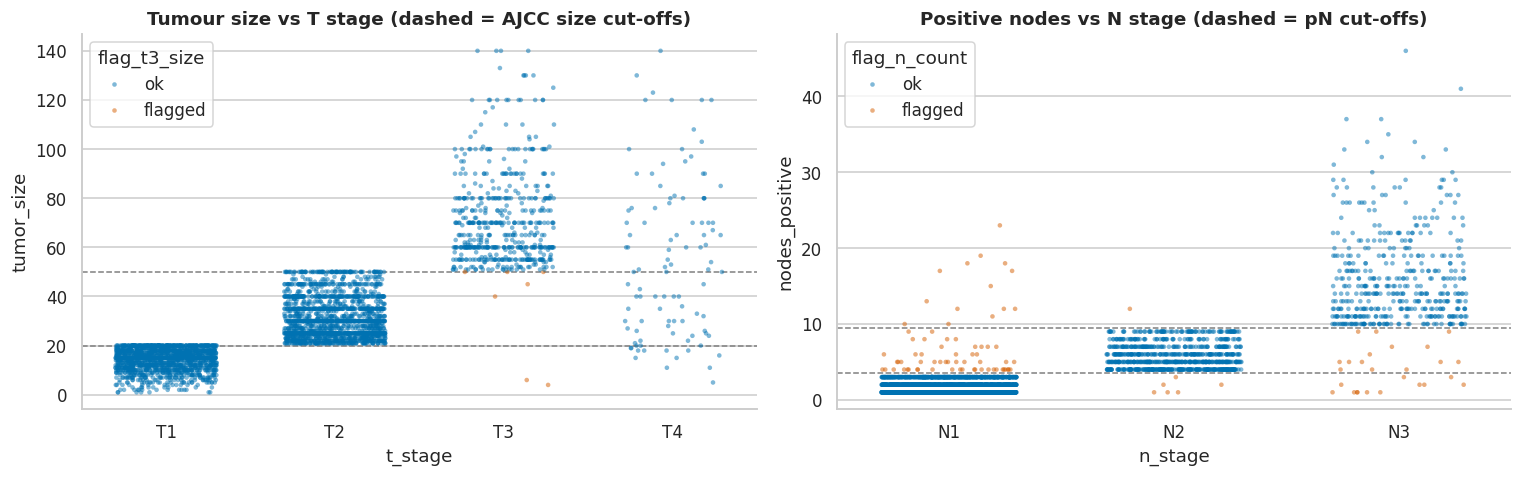

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.stripplot(data=df, x="t_stage", y="tumor_size", order=C.ORDINAL_LEVELS["t_stage"], ax=axes[0],
              hue=flags["flag_t3_size"].map({True: "flagged", False: "ok"}),
              palette={"ok": "#0072B2", "flagged": "#D55E00"}, size=3, alpha=.5, jitter=.3)
for y in (20, 50):
    axes[0].axhline(y, ls="--", c="grey", lw=1)
axes[0].set_title("Tumour size vs T stage (dashed = AJCC size cut-offs)")
sns.stripplot(data=df, x="n_stage", y="nodes_positive", order=C.ORDINAL_LEVELS["n_stage"], ax=axes[1],
              hue=flags["flag_n_count"].map({True: "flagged", False: "ok"}),
              palette={"ok": "#0072B2", "flagged": "#D55E00"}, size=3, alpha=.5, jitter=.3)
for y in (3.5, 9.5):
    axes[1].axhline(y, ls="--", c="grey", lw=1)
axes[1].set_title("Positive nodes vs N stage (dashed = pN cut-offs)")
fig.tight_layout(); save_fig(fig, "02_consistency_flags"); plt.show()

**Does being flagged relate to the outcome?** If flagged rows had very different mortality, they would need special handling.

In [10]:
any_flag = flags.any(axis=1)
tab = df.groupby(any_flag)["event"].agg(["size", "sum", "mean"]).rename(index={False: "not flagged", True: "flagged"})
tab.columns = ["n", "deaths", "death_rate"]
from scipy.stats import fisher_exact
ct = pd.crosstab(any_flag, df.event)
odds, p = fisher_exact(ct)
print(tab.round(3)); print(f"\nFisher exact test: OR={odds:.2f}, p={p:.3f}")

                n  deaths  death_rate
not flagged  3917     594       0.152
flagged       107      22       0.206

Fisher exact test: OR=1.45, p=0.134


Decision: the 108 flagged rows stay in, unchanged. The flag columns are saved in the interim file so a sensitivity analysis can drop them later.

## 5. The duplicate row

In [11]:
dup_mask = df.duplicated(keep=False)
df[dup_mask]

,age,race,marital_status,t_stage,n_stage,stage_6th,grade,a_stage,tumor_size,estrogen_status,progesterone_status,nodes_examined,nodes_positive,survival_months,status,event
1009,63,White,Married,T1,N1,IIA,2,Regional,17,Positive,Positive,9,1,56,Alive,0
1010,63,White,Married,T1,N1,IIA,2,Regional,17,Positive,Positive,9,1,56,Alive,0


Kept. Identical records are plausible with coarse variables and no patient ID. One row has no practical effect.

## 6. Outliers: statistical vs clinical view

In [12]:
rows = []
for c in C.NUMERIC_COLS + ["survival_months"]:
    q1, q3 = df[c].quantile([.25, .75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    rows.append({"column": c, "min": df[c].min(), "max": df[c].max(), "IQR_low": lo, "IQR_high": hi,
                 "n_outside_IQR_fence": int(((df[c] < lo) | (df[c] > hi)).sum())})
pd.DataFrame(rows)

,column,min,max,IQR_low,IQR_high,n_outside_IQR_fence
0,age,30,69,26.0,82.0,0
1,tumor_size,1,140,-17.0,71.0,222
2,nodes_examined,1,61,-6.0,34.0,72
3,nodes_positive,1,46,-5.0,11.0,344
4,survival_months,1,107,5.0,141.0,18


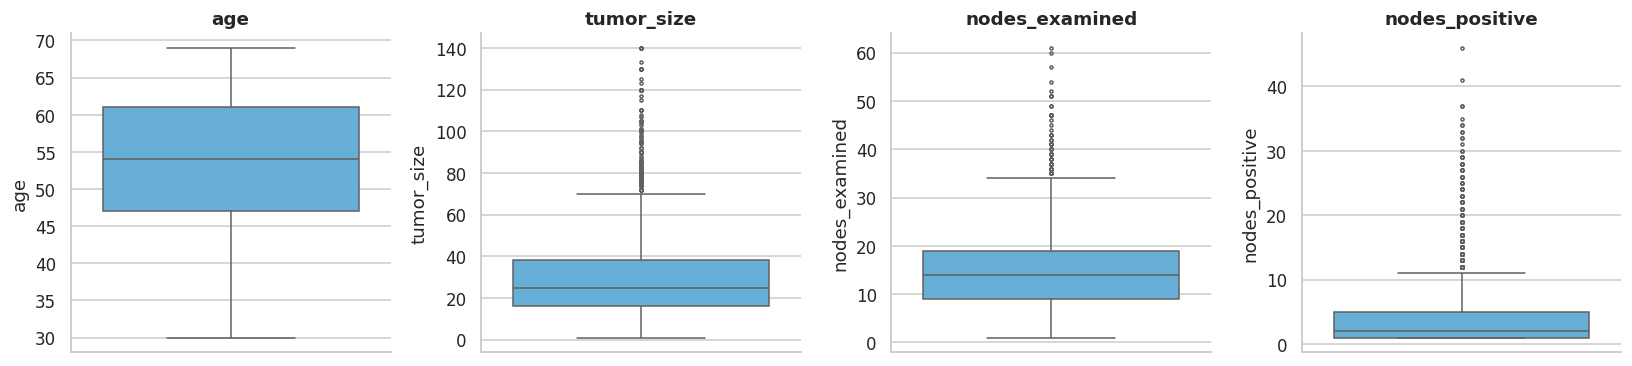

In [13]:
fig, axes = plt.subplots(1, 4, figsize=(15, 3.5))
for ax, c in zip(axes, C.NUMERIC_COLS):
    sns.boxplot(y=df[c], ax=ax, color="#56B4E9", fliersize=2)
    ax.set_title(c)
fig.tight_layout(); save_fig(fig, "02_boxplots"); plt.show()

The extreme values (tumours up to 140 mm, up to 46 positive nodes) are clinically real and belong to the highest-risk patients. They are kept. Skew is handled with `log1p` in notebook 05.

## 7. Save the interim dataset and data dictionary

In [14]:
interim = pd.concat([df, flags.astype(int)], axis=1)
C.INTERIM_DIR.mkdir(parents=True, exist_ok=True)
interim.to_csv(C.CLEAN_DATA_PATH, index=False)
print("saved", C.CLEAN_DATA_PATH.relative_to(ROOT), interim.shape)

saved data/interim/seer_clean.csv (4024, 20)


In [15]:
desc = {
    "age": "Age at diagnosis (years)",
    "race": "Race recode (White / Black / Other = American Indian, AK Native, Asian, Pacific Islander)",
    "marital_status": "Marital status at diagnosis",
    "t_stage": "AJCC 6th ed. primary tumour category",
    "n_stage": "AJCC 6th ed. regional node category",
    "stage_6th": "AJCC 6th ed. stage group (derived from T and N; not a model input)",
    "grade": "Histological grade 1-4 (well -> undifferentiated)",
    "a_stage": "SEER summary stage: Regional or Distant",
    "tumor_size": "Tumour size (mm)",
    "estrogen_status": "Oestrogen receptor status",
    "progesterone_status": "Progesterone receptor status",
    "nodes_examined": "Number of regional lymph nodes examined",
    "nodes_positive": "Number of regional lymph nodes positive",
    "survival_months": "Months from diagnosis to death or last follow-up (OUTCOME - never a feature)",
    "status": "Vital status at last follow-up (OUTCOME)",
    "event": "1 = Dead, 0 = Alive/censored (OUTCOME)",
}
dd = pd.DataFrame({
    "column": list(desc),
    "dtype": [str(df[c].dtype) for c in desc],
    "role": ["outcome" if c in C.LEAKAGE_COLS else ("excluded" if c == "stage_6th" else "feature") for c in desc],
    "values": [(f"{df[c].min()} - {df[c].max()}" if df[c].dtype.kind in "if" else ", ".join(map(str, sorted(df[c].unique()))))
               for c in desc],
    "description": list(desc.values()),
})
dd

,column,dtype,role,values,description
0,age,int64,feature,30 - 69,Age at diagnosis (years)
1,race,object,feature,"Black, Other, White",Race recode (White / Black / Other = American ...
2,marital_status,object,feature,"Divorced, Married, Separated, Single, Widowed",Marital status at diagnosis
3,t_stage,object,feature,"T1, T2, T3, T4",AJCC 6th ed. primary tumour category
4,n_stage,object,feature,"N1, N2, N3",AJCC 6th ed. regional node category
5,stage_6th,object,excluded,"IIA, IIB, IIIA, IIIB, IIIC",AJCC 6th ed. stage group (derived from T and N...
6,grade,int64,feature,1 - 4,Histological grade 1-4 (well -> undifferentiated)
7,a_stage,object,feature,"Distant, Regional",SEER summary stage: Regional or Distant
8,tumor_size,int64,feature,1 - 140,Tumour size (mm)
9,estrogen_status,object,feature,"Negative, Positive",Oestrogen receptor status


## Summary

- 4,024 rows × 16 columns, typed, no missing values, all hard checks pass.
- `stage_6th` is fully determined by T and N, so it is not used as a model input.
- 107 rows have clinical consistency flags. They are kept.
- The duplicate row and extreme values are kept.